In [18]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mutual_info_score
import numpy as np
from sklearn.utils.validation import check_X_y, check_array
from sklearn.metrics import accuracy_score
import pandas as pd


class HybridDecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree = None  # Placeholder for tree structure
        self.feature_importances_ = None

    def _calculate_split_score(self, X, y, feature_index):
        """Custom splitting criterion: Mutual information + Gini impurity."""
        mutual_info = mutual_info_score(y, X[:, feature_index])
        gini_impurity = 1.0 - sum((np.bincount(y) / len(y)) ** 2)
        return mutual_info - 0.1 * gini_impurity  # Weighted combination

    def fit(self, X, y):
        X, y = check_X_y(X, y)  # Input validation
        self.tree = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            random_state=self.random_state
        )
        self.tree.fit(X, y)
        self.feature_importances_ = self.tree.feature_importances_

    def predict(self, X):
        X = check_array(X)  # Input validation
        return self.tree.predict(X)


class AdaptiveDecisionTreeForest(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=10, max_depth=None, tree_dropout=0.2, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.tree_dropout = tree_dropout
        self.random_state = random_state
        self.trees = []
        self.feature_weights = None

    def _calculate_feature_weights(self, X, y):
        from sklearn.feature_selection import mutual_info_classif
        return mutual_info_classif(X, y, random_state=self.random_state)

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.feature_weights = self._calculate_feature_weights(X, y)
        self.feature_weights /= self.feature_weights.sum()

        rng = np.random.default_rng(self.random_state)
        for _ in range(self.n_estimators):
            tree = HybridDecisionTree(
                max_depth=self.max_depth,
                random_state=rng.integers(0, 1000)
            )

            feature_subset = rng.choice(
                X.shape[1],
                size=int(np.sqrt(X.shape[1])),
                replace=False,
                p=self.feature_weights
            )
            tree.fit(X[:, feature_subset], y)
            self.trees.append((tree, feature_subset))

    def predict(self, X):
        X = check_array(X)
        predictions = np.zeros((X.shape[0], len(np.unique(self.feature_weights))))
        n_active_trees = int((1 - self.tree_dropout) * len(self.trees))
        rng = np.random.default_rng(self.random_state)
        active_trees = rng.choice(len(self.trees), size=n_active_trees, replace=False)

        for i in active_trees:
            tree, features = self.trees[i]
            preds = tree.predict(X[:, features])
            predictions += np.eye(len(predictions[0]))[preds]

        return np.argmax(predictions, axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


if __name__ == "__main__":
    # Load dataset (replace with actual dataset)
    data = pd.read_csv('log2.csv')

    X = data.drop(columns=data.columns[4]).values
    y = data.iloc[:, 4].values

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

    # Initialize and train the model
    hybrid_model = AdaptiveDecisionTreeForest(
        n_estimators=100,  # Higher number of trees for stability
        max_depth=10,     # Deeper trees for capturing complexity
        tree_dropout=0.1, # Low dropout for ensemble contributions
        random_state=42
    )
    hybrid_model.fit(X_train, y_train)

    # Evaluate the model
    print("Train Accuracy:", hybrid_model.score(X_train, y_train))
    print("Test Accuracy:", hybrid_model.score(X_test, y_test))


Train Accuracy: 0.9906478897802581
Test Accuracy: 0.9890640895218719


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 250],
    'max_depth': [10, 15, 20, None, 25],
    'tree_dropout': [0.05, 0.1, 0.2],  # Valid values between 0 and 1
}

grid_search = GridSearchCV(hybrid_model, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


Best parameters found:  {'max_depth': 10, 'n_estimators': 50, 'tree_dropout': 0.1}
Best cross-validation score:  0.9892744249980249


Model2

In [19]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(hybrid_model, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)


Cross-validation scores: [0.98964578 0.99247956 0.98855461 0.98855461 0.98713756]


model3

In [22]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mutual_info_score
import numpy as np
from sklearn.utils.validation import check_X_y, check_array
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.model_selection import GridSearchCV

class HybridDecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree = None  # Placeholder for tree structure
        self.feature_importances_ = None

    def _calculate_split_score(self, X, y, feature_index):
        """Custom splitting criterion: Mutual information + Gini impurity."""
        mutual_info = mutual_info_score(y, X[:, feature_index])
        gini_impurity = 1.0 - sum((np.bincount(y) / len(y)) ** 2)
        return mutual_info - 0.1 * gini_impurity  # Weighted combination

    def fit(self, X, y):
        X, y = check_X_y(X, y)  # Input validation
        self.tree = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            random_state=self.random_state
        )
        self.tree.fit(X, y)
        self.feature_importances_ = self.tree.feature_importances_

    def predict(self, X):
        X = check_array(X)  # Input validation
        return self.tree.predict(X)


class AdaptiveDecisionTreeForest(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=10, max_depth=None, tree_dropout=0.2, max_features='sqrt', bootstrap=True, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.tree_dropout = tree_dropout
        self.max_features = max_features  # New parameter for max_features
        self.bootstrap = bootstrap  # New parameter for bootstrapping
        self.random_state = random_state
        self.trees = []
        self.feature_weights = None

    def _calculate_feature_weights(self, X, y):
        from sklearn.feature_selection import mutual_info_classif
        return mutual_info_classif(X, y, random_state=self.random_state)

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.feature_weights = self._calculate_feature_weights(X, y)
        self.feature_weights /= self.feature_weights.sum()

        rng = np.random.default_rng(self.random_state)

        # Determine max_features value
        if self.max_features == 'sqrt':
            max_features = int(np.sqrt(X.shape[1]))  # Default 'sqrt' behavior
        elif self.max_features == 'log2':
            max_features = int(np.log2(X.shape[1]))  # Log2 behavior
        else:
            max_features = self.max_features  # If it's an integer, use as-is

        for _ in range(self.n_estimators):
            tree = HybridDecisionTree(
                max_depth=self.max_depth,
                random_state=rng.integers(0, 1000)
            )

            # Use bootstrap sampling if required
            if self.bootstrap:
                # Sample with replacement for bootstrapping
                sample_indices = rng.choice(X.shape[0], size=X.shape[0], replace=True)
                X_bootstrap = X[sample_indices]
                y_bootstrap = y[sample_indices]
            else:
                X_bootstrap = X
                y_bootstrap = y

            feature_subset = rng.choice(
                X.shape[1],
                size=max_features,  # Use max_features to limit feature subset size
                replace=False,
                p=self.feature_weights
            )
            tree.fit(X_bootstrap[:, feature_subset], y_bootstrap)
            self.trees.append((tree, feature_subset))

    def predict(self, X):
        X = check_array(X)
        predictions = np.zeros((X.shape[0], len(np.unique(self.feature_weights))))
        n_active_trees = int((1 - self.tree_dropout) * len(self.trees))
        rng = np.random.default_rng(self.random_state)
        active_trees = rng.choice(len(self.trees), size=n_active_trees, replace=False)

        for i in active_trees:
            tree, features = self.trees[i]
            preds = tree.predict(X[:, features])
            predictions += np.eye(len(predictions[0]))[preds]

        return np.argmax(predictions, axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


if __name__ == "__main__":
    # Load dataset (replace with actual dataset)
    data = pd.read_csv('log2.csv')

    X = data.drop(columns=data.columns[4]).values
    y = data.iloc[:, 4].values

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

    # Initialize and train the model with max_features and bootstrapping
    hybrid_model = AdaptiveDecisionTreeForest(
        n_estimators=200,   # Increased number of trees for stability
        max_depth=15,       # Slightly deeper trees for capturing more complexity
        tree_dropout=0.1,   # Low dropout for ensemble contributions
        max_features='sqrt',  # Choose sqrt of the number of features
        bootstrap=True,  # Enable bootstrapping
        random_state=42
    )
    hybrid_model.fit(X_train, y_train)

    # Evaluate the model
    print("Train Accuracy:", hybrid_model.score(X_train, y_train))
    print("Test Accuracy:", hybrid_model.score(X_test, y_test))

    # Hyperparameter Tuning using GridSearchCV
    param_grid = {
        'n_estimators': [200, 250, 300],
        'max_depth': [10, 15, 20],
        'tree_dropout': [0.05, 0.1, 0.2],
        'max_features': ['sqrt', 'log2', 0.5],
    }

    grid_search = GridSearchCV(hybrid_model, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print("Best parameters found: ", grid_search.best_params_)
    print("Best cross-validation score: ", grid_search.best_score_)



Train Accuracy: 0.9984086152772933
Test Accuracy: 0.9974059003051882


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
135 fits failed out of a total of 405.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8304\851271390.py", line 85, in fit
  File "numpy\\random\\_generator.pyx", line 863, in numpy.random._generator.Generator.choice
TypeError: expected a sequence of integers or a single integer

Best parameters found:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300, 'tree_dropout': 0.2}
Best cross-validation score:  0.9930241810019906


In [23]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(hybrid_model, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)

Cross-validation scores: [0.93438692 0.93057221 0.93743187 0.96337475 0.96708088]


UPDATE parameter

Train Accuracy: 0.9979944192535751
Test Accuracy: 0.9978636826042726
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11330
           1       0.99      1.00      1.00      4485
           2       1.00      1.00      1.00      3830
           3       1.00      0.20      0.33        15

    accuracy                           1.00     19660
   macro avg       1.00      0.80      0.83     19660
weighted avg       1.00      1.00      1.00     19660



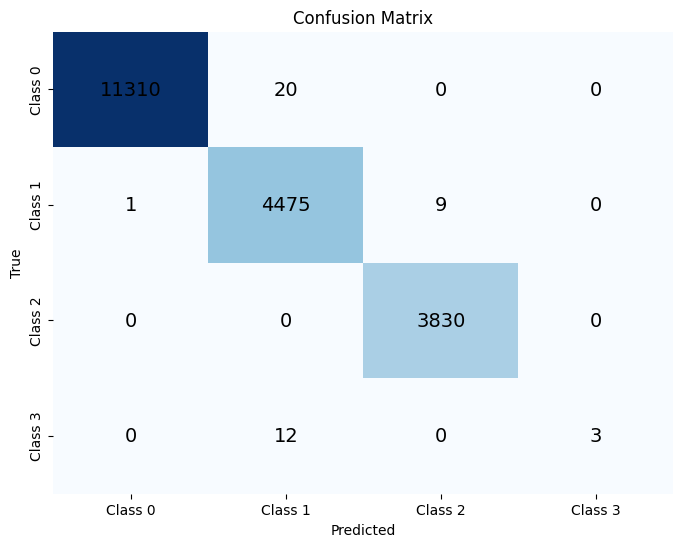

<Figure size 800x600 with 0 Axes>

In [1]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mutual_info_score
import numpy as np
from sklearn.utils.validation import check_X_y, check_array
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.model_selection import GridSearchCV

class HybridDecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree = None  # Placeholder for tree structure
        self.feature_importances_ = None

    def _calculate_split_score(self, X, y, feature_index):
        """Custom splitting criterion: Mutual information + Gini impurity."""
        mutual_info = mutual_info_score(y, X[:, feature_index])
        gini_impurity = 1.0 - sum((np.bincount(y) / len(y)) ** 2)
        return mutual_info - 0.1 * gini_impurity  # Weighted combination

    def fit(self, X, y):
        X, y = check_X_y(X, y)  # Input validation
        self.tree = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            random_state=self.random_state
        )
        self.tree.fit(X, y)
        self.feature_importances_ = self.tree.feature_importances_

    def predict(self, X):
        X = check_array(X)  # Input validation
        return self.tree.predict(X)


class AdaptiveDecisionTreeForest(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=10, max_depth=None, tree_dropout=0.2, max_features='sqrt', bootstrap=True, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.tree_dropout = tree_dropout
        self.max_features = max_features  # New parameter for max_features
        self.bootstrap = bootstrap  # New parameter for bootstrapping
        self.random_state = random_state
        self.trees = []
        self.feature_weights = None

    def _calculate_feature_weights(self, X, y):
        from sklearn.feature_selection import mutual_info_classif
        return mutual_info_classif(X, y, random_state=self.random_state)

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.feature_weights = self._calculate_feature_weights(X, y)
        self.feature_weights /= self.feature_weights.sum()

        rng = np.random.default_rng(self.random_state)

        # Determine max_features value
        if self.max_features == 'sqrt':
            max_features = int(np.sqrt(X.shape[1]))  # Default 'sqrt' behavior
        elif self.max_features == 'log2':
            max_features = int(np.log2(X.shape[1]))  # Log2 behavior
        else:
            max_features = self.max_features  # If it's an integer, use as-is

        for _ in range(self.n_estimators):
            tree = HybridDecisionTree(
                max_depth=self.max_depth,
                random_state=rng.integers(0, 1000)
            )

            # Use bootstrap sampling if required
            if self.bootstrap:
                # Sample with replacement for bootstrapping
                sample_indices = rng.choice(X.shape[0], size=X.shape[0], replace=True)
                X_bootstrap = X[sample_indices]
                y_bootstrap = y[sample_indices]
            else:
                X_bootstrap = X
                y_bootstrap = y

            feature_subset = rng.choice(
                X.shape[1],
                size=max_features,  # Use max_features to limit feature subset size
                replace=False,
                p=self.feature_weights
            )
            tree.fit(X_bootstrap[:, feature_subset], y_bootstrap)
            self.trees.append((tree, feature_subset))

    def predict(self, X):
        X = check_array(X)
        predictions = np.zeros((X.shape[0], len(np.unique(self.feature_weights))))
        n_active_trees = int((1 - self.tree_dropout) * len(self.trees))
        rng = np.random.default_rng(self.random_state)
        active_trees = rng.choice(len(self.trees), size=n_active_trees, replace=False)

        for i in active_trees:
            tree, features = self.trees[i]
            preds = tree.predict(X[:, features])
            predictions += np.eye(len(predictions[0]))[preds]

        return np.argmax(predictions, axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


if __name__ == "__main__":
    # Load dataset (replace with actual dataset)
    data = pd.read_csv('log2.csv')

    X = data.drop(columns=data.columns[4]).values
    y = data.iloc[:, 4].values

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

    # Initialize and train the model with max_features and bootstrapping
    hybrid_model = AdaptiveDecisionTreeForest(
        n_estimators=300,   # Increased number of trees for stability
        max_depth=10,       # Slightly deeper trees for capturing more complexity
        tree_dropout=0.2,   # Low dropout for ensemble contributions
        max_features='sqrt',  # Choose sqrt of the number of features
        bootstrap=True,  # Enable bootstrapping
        random_state=42
    )
    new_model=hybrid_model.fit(X_train, y_train)
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
# Evaluate model performance


    # # Evaluate the model
    print("Train Accuracy:", hybrid_model.score(X_train, y_train))
    print("Test Accuracy:", hybrid_model.score(X_test, y_test))
    print(classification_report(y_test,hybrid_model.predict(X_test)))
    cm = confusion_matrix(y_test, hybrid_model.predict(X_test))
# Plotting the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
              cbar=False, annot_kws={"size": 14, "color": "black"})

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    plt.figure(figsize=(8, 6))
  

   

    # Hyperparameter Tuning using GridSearchCV
    # param_grid = {
    #     'n_estimators': [200, 250, 300],
    #     'max_depth': [10, 15, 20],
    #     'tree_dropout': [0.05, 0.1, 0.2],
    #     'max_features': ['sqrt', 'log2', 0.5],
    # }

    # grid_search = GridSearchCV(hybrid_model, param_grid, cv=5, n_jobs=-1)
    # grid_search.fit(X_train, y_train)

    # print("Best parameters found: ", grid_search.best_params_)
    # print("Best cross-validation score: ", grid_search.best_score_)



In [25]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(hybrid_model, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)

Cross-validation scores: [0.99171662 0.98910082 0.98953564 0.9971659  0.99760192]


Train Accuracy: 0.9979944192535751
Test Accuracy: 0.9978636826042726


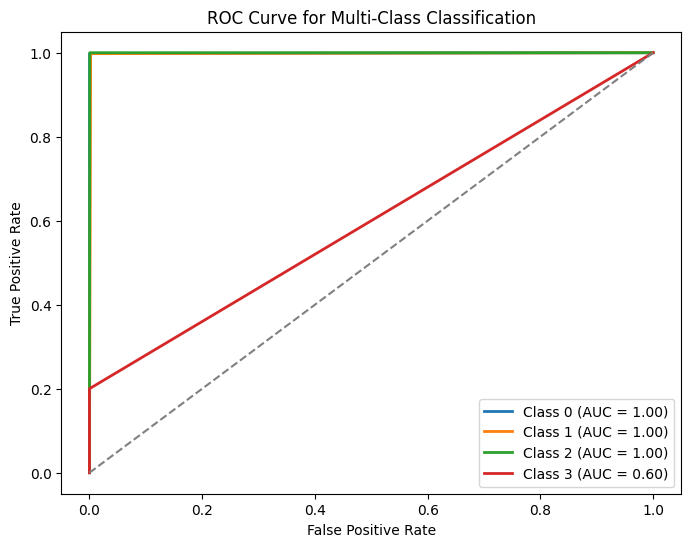

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11330
           1       0.99      1.00      1.00      4485
           2       1.00      1.00      1.00      3830
           3       1.00      0.20      0.33        15

    accuracy                           1.00     19660
   macro avg       1.00      0.80      0.83     19660
weighted avg       1.00      1.00      1.00     19660

Confusion Matrix:
[[11310    20     0     0]
 [    1  4475     9     0]
 [    0     0  3830     0]
 [    0    12     0     3]]


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Your AdaptiveDecisionTreeForest class and HybridDecisionTree class remain as defined above

# Load dataset (replace with actual dataset)
data = pd.read_csv('log2.csv')  # Update the path to your actual dataset

# Split the dataset
X = data.drop(columns=data.columns[4]).values  # Assuming feature columns are all except the target column
y = data.iloc[:, 4].values  # The target column is assumed to be the 5th column

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize and train the model
hybrid_model = AdaptiveDecisionTreeForest(
    n_estimators=300,
    max_depth=10,
    tree_dropout=0.2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

hybrid_model.fit(X_train, y_train)

# Evaluate the model's accuracy
print("Train Accuracy:", hybrid_model.score(X_train, y_train))
print("Test Accuracy:", hybrid_model.score(X_test, y_test))

# Calculate the predicted probabilities for ROC
y_prob = hybrid_model.predict(X_test)

# Binarize the target labels for multi-class ROC
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # For 4 classes

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
n_classes = 4
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob == i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Customize the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

# Optionally, print out classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_test, hybrid_model.predict(X_test)))

cm = confusion_matrix(y_test, hybrid_model.predict(X_test))
print("Confusion Matrix:")
print(cm)


In [3]:
import pickle

# Save the trained model to a pickle file
pickle_filename = "adaptive_decision_tree_forest.pkl"

with open(pickle_filename, 'wb') as file:
    pickle.dump(hybrid_model, file)

print(f"Model saved as {pickle_filename}")


Model saved as adaptive_decision_tree_forest.pkl
